# Preprocessing 

## 1. Load the data

In [ ]:
from ezphot.utils import SDTDataQuerier
# If you connected the database, you can easily sync the data from the database. 
sdtquery = SDTDataQuerier()
sdtquery.help()

Help for SDTDataQuerier


Public methods:
- show_obsdestdata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obsdestfolder(folder_key: str = '*')
- show_obssourcedata(foldername: str, show_only_numbers: bool = False, pattern: str = '*.fits')
- show_obssourcefolder(folder_key: str = '*')
- show_scidestdata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', pattern: str = '*.fits')
- show_scisourcedata(targetname: str, show_only_numbers: bool = False, key: str = 'filter', file_pattern: str = '*.fits')
- show_scisourcefolder(folder_key: str = '*')
- sync_obsdata(foldername: str, file_pattern: str = '*.fits', ignore_exists: bool = True)
- sync_scidata(targetname: str, file_pattern: str = '*.fits', ignore_exists: bool = True)


In [8]:
# sync_scidata method will run multiple rsync between Science Source directory and destination directory.
print('Source directory:', sdtquery.helper.config['SDTDATA_OBSSOURCEDIR'])
print('Target directory:', sdtquery.helper.config['SDTDATA_OBSDESTDIR'])
obsdate_name = '2025-09-05_gain2750'
sdtquery.sync_obsdata(foldername = obsdate_name, file_pattern = '*T00290*.fits')

Source directory: /home/hhchoi1022/ezphot/data/connecteddata/7DT/obsdata
Target directory: /home/hhchoi1022/ezphot/data/obsdata/7DT
Running: rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *T00290*.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/obsdata/7DT01/2025-09-05_gain2750/ /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT01/2025-09-05_gain2750/
Running:Running:Running:Running:Running:Running:Running:Running:Running:Running:         rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *T00290*.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/obsdata/7DT07/2025-09-05_gain2750/ /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT07/2025-09-05_gain2750/rsync -av --info=progress2 --no-inc-recursive --prune-empty-dirs --ignore-existing --include */ --include *T00290*.fits --exclude * /home/hhchoi1022/ezphot/data/connecteddata/7DT/obsdata/7DT06/2025-09-05_gai

In [ ]:
# Then, you can query your data with DataBrowser class. 
# Since the data is copied to your private directory (['SCIDATA_SCIDESTDIR'](e.g. ~/ezphot/data/scidata by default) in configuration), you can use it as your own data. 
# You can also use it as a context for ezphot. 
from ezphot.utils import DataBrowser
dbrowser = DataBrowser('obsdata')
# You can query the data with the below keys.
for key, value in dbrowser.keys.items():
    print(key, value)


observatory {'7DT'}
telkey set()
objname set()
telname {'7DT11', '7DT01', '7DT10', '7DT03', '7DT07', '7DT08', '7DT16', '7DT14', '7DT06', '7DT12', '7DT13'}
filter set()
imgtype set()
obsdate {'2025-09-05_gain2750'}


In [11]:
dbrowser.obsdate = obsdate_name
dbrowser.search('*.fits', return_type = 'path')

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/obsdata/*/*/2025-09-05_gain2750/*.fits'


['/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_233955_T00290_m700_1x1_100.0s_0001.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234653_T00290_m725_1x1_100.0s_0001.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234508_T00290_m725_1x1_100.0s_0000.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234838_T00290_m725_1x1_100.0s_0002.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234140_T00290_m700_1x1_100.0s_0002.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_233809_T00290_m700_1x1_100.0s_0000.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT03/2025-09-05_gain2750/7DT03_20250905_233808_T00290_m450_1x1_100.0s_0000.fits',
 '/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT03/2025-09-05_gain2750/7DT03_20250905_234653_T00290_m475_1x1_100.0s_0001

In [12]:
# If you wish to get the ScienceImage object, 
target_imgset = dbrowser.search('*.fits', return_type = 'science')
target_imglist = target_imgset.target_images
# If you wish to get the metadata table from the keys, 
metadata_table = dbrowser.search('*.fits', return_type = 'imginfo')

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/obsdata/*/*/2025-09-05_gain2750/*.fits'


Loading Science Images: 100%|██████████| 66/66 [00:00<00:00, 93.15it/s] 

[INFO] Found 66 files matching '/home/hhchoi1022/ezphot/data/obsdata/*/*/2025-09-05_gain2750/*.fits'


Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750
Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT12/2025-09-05_gain2750
Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT01/2025-09-05_gain2750Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT03/2025-09-05_gain2750
Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT14/2025-09-05_gain2750Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT16/2025-09-05_gain2750Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT11/2025-09-05_gain2750Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT07/2025-09-05_gain2750Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT06/2025-09-05_gain2750Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT13/2025-09-05_gain2750
Loaded 6 FITS files from /home/hhchoi1022/ezphot/data/obsdata/7DT/7DT10/2025-09-05_gai

Total FITS files combined: 6



Total FITS files combined: 6


In [13]:
metadata_table

file,altitude,azimuth,ccd-temp,gain,filter,imgtype,exptime,obsdate,locdate,jd,mjd,binning,object,objctid,obsmode,specmode,note,telescop
str121,str32,str32,str32,str21,str4,str5,str32,str23,str23,str32,str32,str21,str6,str32,str4,str7,str4,str5
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_233955_T00290_m700_1x1_100.0s_0001.fits,39.837596,179.72268,-10.0,2750,m700,LIGHT,100.0,2025-09-05T23:39:55.000,2025-09-05 19:39:55.000,2460924.486053241,60923.98605324074,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT08
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234653_T00290_m725_1x1_100.0s_0001.fits,39.840043,180.091172,-10.0,2750,m725,LIGHT,100.0,2025-09-05T23:46:53.000,2025-09-05 19:46:53.000,2460924.4908912037,60923.990891203706,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT08
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234508_T00290_m725_1x1_100.0s_0000.fits,39.840357,179.998559,-9.8,2750,m725,LIGHT,100.0,2025-09-05T23:45:08.000,2025-09-05 19:45:08.000,2460924.489675926,60923.98967592593,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT08
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234838_T00290_m725_1x1_100.0s_0002.fits,39.83912,180.183768,-10.0,2750,m725,LIGHT,100.0,2025-09-05T23:48:38.000,2025-09-05 19:48:38.000,2460924.4921064815,60923.992106481484,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT08
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_234140_T00290_m700_1x1_100.0s_0002.fits,39.839148,179.815416,-10.1,2750,m700,LIGHT,100.0,2025-09-05T23:41:40.000,2025-09-05 19:41:40.000,2460924.4872685187,60923.98726851852,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT08
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT08/2025-09-05_gain2750/7DT08_20250905_233809_T00290_m700_1x1_100.0s_0000.fits,39.83547,179.629828,-9.8,2750,m700,LIGHT,100.0,2025-09-05T23:38:09.000,2025-09-05 19:38:09.000,2460924.484826389,60923.984826388885,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT08
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT03/2025-09-05_gain2750/7DT03_20250905_233808_T00290_m450_1x1_100.0s_0000.fits,39.820706,179.644698,-10.1,2750,m450,LIGHT,100.0,2025-09-05T23:38:08.000,2025-09-05 19:38:08.000,2460924.4848148148,60923.984814814816,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT03
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT03/2025-09-05_gain2750/7DT03_20250905_234653_T00290_m475_1x1_100.0s_0001.fits,39.82478,180.107488,-10.0,2750,m475,LIGHT,100.0,2025-09-05T23:46:53.000,2025-09-05 19:46:53.000,2460924.4908912037,60923.990891203706,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT03
/home/hhchoi1022/ezphot/data/obsdata/7DT/7DT03/2025-09-05_gain2750/7DT03_20250905_234508_T00290_m475_1x1_100.0s_0000.fits,39.825207,180.014533,-10.0,2750,m475,LIGHT,100.0,2025-09-05T23:45:08.000,2025-09-05 19:45:08.000,2460924.489675926,60923.98967592593,1,T00290,9473692bf1874a48a7492f0f1ad94624,Spec,specall,None,7DT03


## 2. Load the master frames

In [ ]:
from ezphot.methods import Preprocess
from ezphot.imageobjects import CalibrationImage

preprocess = Preprocess()
preprocess.help()

mbias_tbl = preprocess.get_masterframe_from_image(target_imglist[0], 'BIAS', max_days = 60)
mdark_tbl = preprocess.get_masterframe_from_image(target_imglist[0], 'DARK', max_days = 60)
mflat_tbl = preprocess.get_masterframe_from_image(target_imglist[0], 'FLAT', max_days = 60) # For flat frames, master frame is needed to specify by the filter

mbias = CalibrationImage(mbias_tbl[0]['file'])
mdark = CalibrationImage(mdark_tbl[0]['file'])
mflat = CalibrationImage(mflat_tbl[0]['file'])

Help for Preprocess

Public methods:
- correct_bd(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_bdf(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, flat_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_bias(target_img: ezphot.imageobjects.scienceimage.ScienceImage, bias_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_dark(target_img: ezphot.imageobjects.scienceimage.ScienceImage, dark_image: ezphot.imageobjects.calibrationimage.CalibrationImage, save: bool = False, **kwargs)
- correct_flat(target_img: ezphot.imageobjects.scienceimage.ScienceImage, flat_im

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '20250723-nm700.fits'}, xlabel='X pixel', ylabel='Y pixel'>)

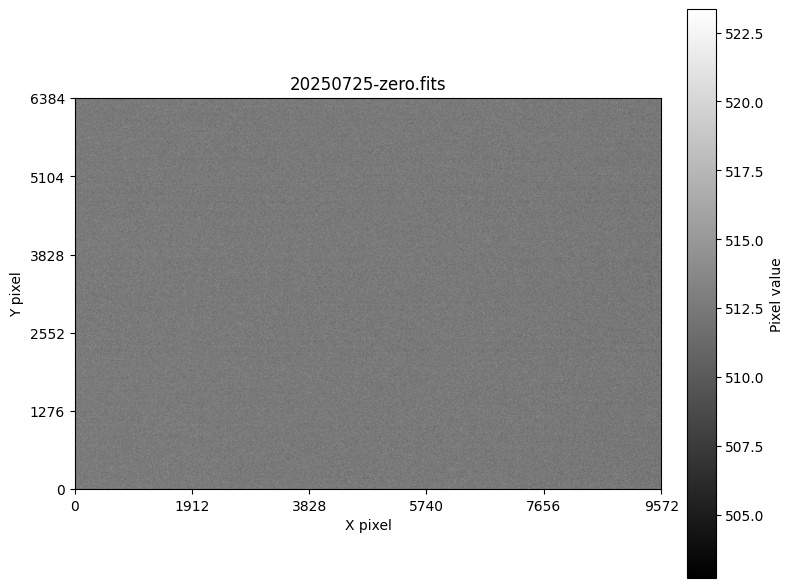

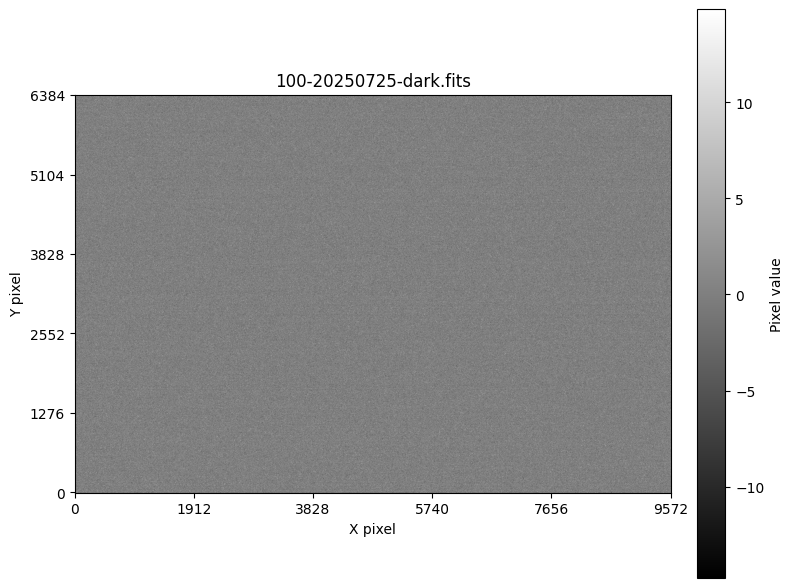

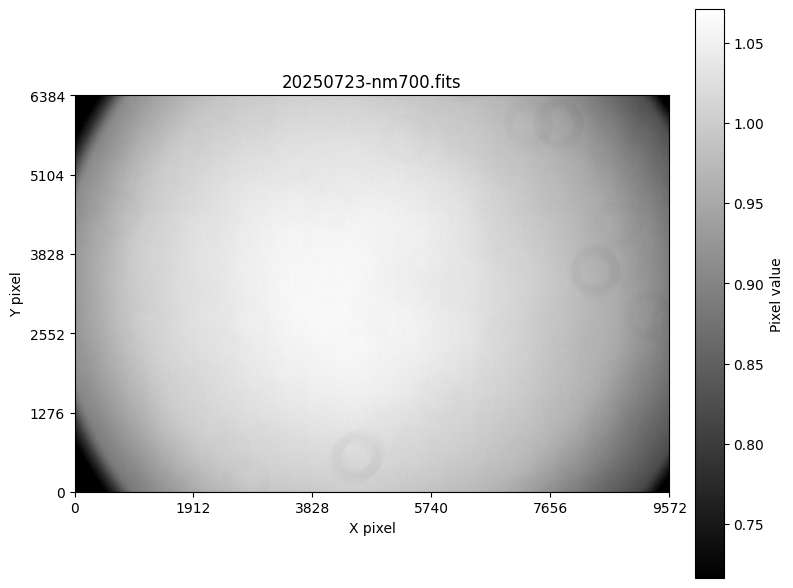

In [18]:
mbias.show()
mdark.show()
mflat.show()

## 3. Preprocess with the master frames

In [ ]:
target_img = target_imglist[0]
corrected_img = preprocess.correct_bdf(
    target_img = target_img,
    bias_image = mbias,
    dark_image = mdark,
    flat_image = mflat,
    save = False
)

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': '7DT08_20250905_233955_T00290_m700_1x1_100.0s_0001.fits'}, xlabel='X pixel', ylabel='Y pixel'>)

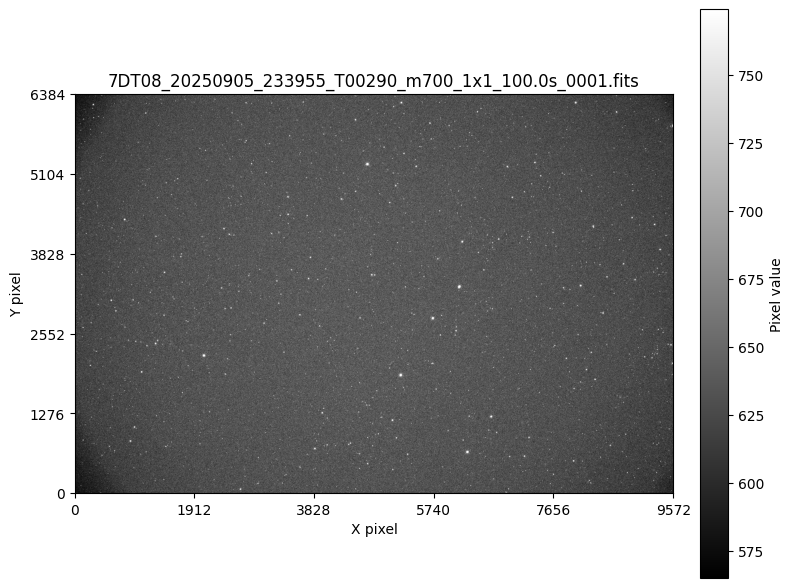

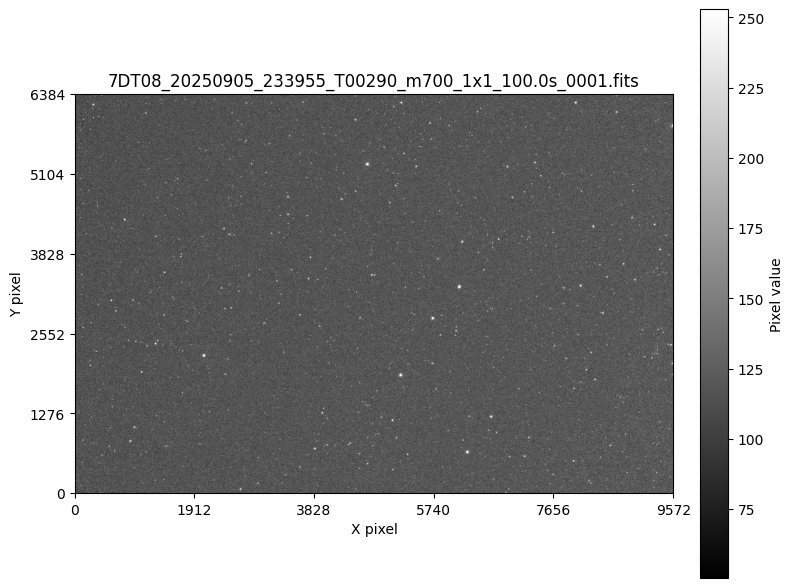

In [26]:
target_img.show()
corrected_img.show()

In [ ]:
# Save the corrected image. 
corrected_img.write()

## 4. Run preprocess for all target_images

In [ ]:
for target_img in target_imglist:
    mbias_tbl = preprocess.get_masterframe_from_image(target_img, 'BIAS', max_days = 60)
    mbias = CalibrationImage(mbias_tbl[0]['file'])
    mdark_tbl = preprocess.get_masterframe_from_image(target_img, 'DARK', max_days = 60)
    mdark = CalibrationImage(mdark_tbl[0]['file'])
    mflat_tbl = preprocess.get_masterframe_from_image(target_img, 'FLAT', max_days = 60)
    mflat = CalibrationImage(mflat_tbl[0]['file'])
    
    preprocess.correct_bdf(
        target_img = target_img,
        bias_image = mbias,
        dark_image = mdark,
        flat_image = mflat,
        save = True)